# Anàlisi estadística — IL-7Rα binders vs non-binders

L'objectiu d'aquest notebook és avaluar si les mètriques computacionals obtingudes per als dissenys contra IL-7Rα permeten discriminar els dissenys que s'uneixen experimentalment al receptor (binders) dels que no ho fan (non-binders). Les mètriques provenen de tres fonts: els indicadors de confiança d'AlphaFold3 (iPTM, pTM, ranking score, PAE cross-chain), les energies de plegament calculades amb Rosetta Relax i les mètriques d'interfície de Rosetta (ΔG, ΔSASA, packstat, hbonds, shape complementarity).

L'anàlisi s'estructura en cinc blocs: descripció i preparació del dataset (Bloc 0), discriminació univariant mètrica per mètrica (Bloc 1), estudi de la redundància i col·linealitat (Bloc 2), reducció de dimensionalitat mitjançant PCA (Bloc 3), model predictiu multivariant (Bloc 4) i anàlisi de robustesa (Bloc 5).

In [67]:
import ast, math, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, balanced_accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, permutation_test_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from IPython.display import display
warnings.filterwarnings('ignore')

col_binder, col_nonbinder = '#9b7bb5', '#e8c97a'   # binder (lila nude), non-binder (groc nude)
class_colors = {'Binder': col_binder, 'Non-binder': col_nonbinder}
strength_colors = {'strong': '#9b7bb5', 'weak': '#c8aee0', 'none': '#aaaaaa', 'unknown': '#dddddd'}

sns.set_style('ticks')
sns.set_context('paper', font_scale=1.15)
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'grid.color'       : '#bbbbbb',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})


## Càrrega del dataset

El dataset integra les mètriques computacionals tant de AlphaFold3, com de Rosetta Relax i les mètriques d'interfície de Rosetta caculades dels 90 dissenys del dataset IL-7Rα.

Les etiquetes de classificació (binder/non-binder) provenen del paper original de RFdiffusion, que va testar experimentalment els 90 dissenys mitjançant un assaig de screening i va identificar 28 binders. La columna `binding_strength` prové d'un segon article de replicació independent que va
recaracteritzar 42 d'aquests complexos, classificant-los en *strong*, *weak* i *none* en funció de la Kd mesurada.

In [68]:
BASE    = Path('/Users/bertaguiu/projects/Scripts/il7ra')
FIGURES = BASE / 'figures'
FIGURES.mkdir(exist_ok=True)

def parse_pae_xchain(val, reducer='mean'):
    if pd.isna(val):
        return np.nan
    try:
        arr = np.array(ast.literal_eval(val) if isinstance(val, str) else val, dtype=float)
    except Exception:
        return np.nan
    if arr.ndim != 2 or arr.shape[0] < 2:
        return np.nan
    off = np.array([arr[0, 1], arr[1, 0]])
    return float(np.nanmin(off) if reducer == 'min' else np.nanmean(off))

df = pd.read_csv(BASE / 'final_il7ra.csv')
df_labels = pd.read_csv(BASE / 'il7ra_binders_dataset.csv')

# Ordenació numèrica per assegurar que Complex1 < Complex2 < ... < Complex90
df = df.sort_values('model', key=lambda s: s.str.extract(r'(\d+)').astype(int)[0]).reset_index(drop=True)
df['design_num'] = df['model'].str.extract(r'(\d+)').astype(int)
df_labels['design_num'] = df_labels['name'].str.extract(r'_(\d+)$').astype(int)

# Afegim les etiquetes experimentals (binding_strength, Kd) per design_num
df = df.merge(df_labels[['design_num', 'is_binder', 'binding_strength', 'Kd_M', 'Kd_numeric']],
              on='design_num', how='left')

df['summary_chain_pair_pae_cross_chain_mean'] = df['summary_chain_pair_pae_min'].apply(parse_pae_xchain)
df['summary_chain_pair_pae_cross_chain_min']  = df['summary_chain_pair_pae_min'].apply(
    lambda x: parse_pae_xchain(x, 'min'))

df['Binding']    = df['is_binder'].map({True: 1, False: 0}).astype('Int64')
df['GroupLabel'] = df['Binding'].map({1: 'Binder', 0: 'Non-binder'})
df['DesignName'] = df['model']

df_labeled = df[df['Binding'].notna()].copy()
n_b, n_nb = int((df_labeled['Binding']==1).sum()), int((df_labeled['Binding']==0).sum())
baseline = n_nb / (n_b + n_nb) # accuracy d'un model trivial que sempre prediu Non-binder

print(f'{n_b} binders  |  {n_nb} non-binders  |  baseline = {baseline:.1%}')
print(df_labeled['binding_strength'].value_counts(dropna=False).to_string()) 


28 binders  |  62 non-binders  |  baseline = 68.9%
NaN       52
strong    17
weak      14
none       7


## Selecció de mètriques i preparació

S'identifiquen les columnes numèriques del dataset excloent seeds, identificadors, etiquetes i les columnes `summary_chain_*`. Es descarten les columnes binàries, constants o amb variabilitat nul·la. 

A partir d'aquest conjunt es generen tres versions de la taula: valors en brut (`df_labeled`) per als tests estadístics, normalització Min-Max per a les visualitzacions comparatives, i estandardització z-score per al panell del Bloc 0 i per als models.

In [69]:
# S'exclouen IDs, seeds i etiquetes
EXCLUDE = {'seed', 'sample', 'Binding', 'design_num',
           'rosetta_n_structures', 'binding_n_structures', 'Kd_numeric', 'Kd_M'}

def get_metrics(df):
    num = df.apply(pd.to_numeric, errors='coerce')
    return [c for c in df.columns
            if c not in EXCLUDE
            and not num[c].isna().all()
            and not set(num[c].dropna().unique()).issubset({0, 1}) # descarta binàries
            and num[c].dropna().nunique() > 1                       # descarta constants
            and pd.api.types.is_numeric_dtype(num[c])]

def short(m):
    return (m.replace('binding_interface_', 'bi_')
             .replace('rosetta_', 'ros_')
             .replace('summary_', 'sum_')
             .replace('_mean', '')
             .replace('_A_B', ''))

metrics = get_metrics(df_labeled)

df_norm = df_labeled.copy()
df_z    = df_labeled.copy()
for m in metrics:
    col = pd.to_numeric(df_labeled[m], errors='coerce')
    lo, hi = col.min(), col.max()
    df_norm[m] = (col - lo) / (hi - lo) if hi > lo else 0.0                 # Min-Max
    df_z[m]    = (col - col.mean()) / col.std() if col.std() > 0 else 0.0   # z-score


---
## Bloc 0 — Descriptiva

Es representa la distribució de classes per deixar clar el desbalanç del dataset (28 binders vs 62 non-binders, baseline = 68.9%) i les distribucions en z-score de les 20 mètriques amb menor p-valor brut per classe. L'estandardització permet comparar mètriques en escales molt diferents en un mateix panell.

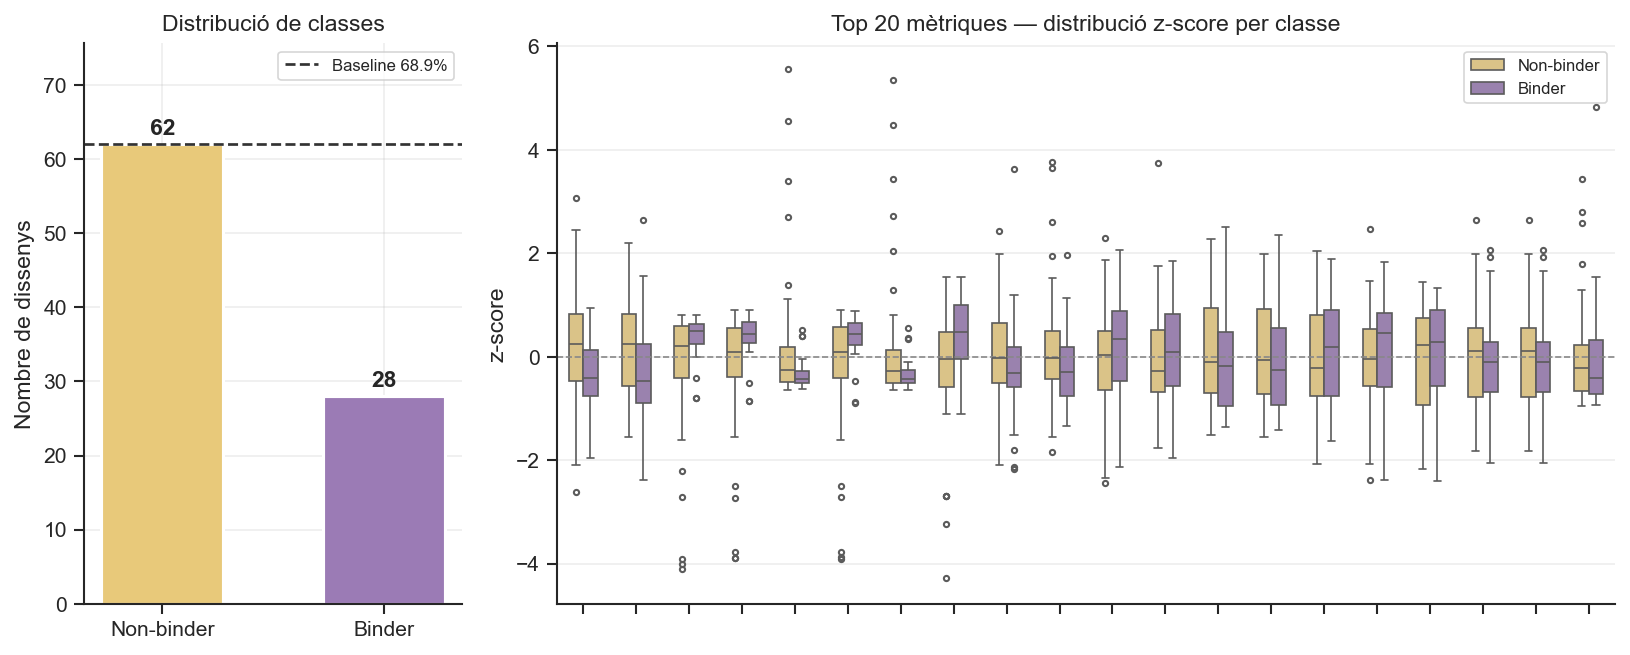

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5),
                          gridspec_kw={'width_ratios': [1, 2.8]})

# Balanç de classes
ax = axes[0]
bars = ax.bar(['Non-binder', 'Binder'], [n_nb, n_b],
              color=[col_nonbinder, col_binder], width=0.55, edgecolor='white', linewidth=1.5)
ax.axhline(baseline * (n_b + n_nb), color='#333333', ls='--', lw=1.3,
           label=f'Baseline {baseline:.1%}')
for bar, n in zip(bars, [n_nb, n_b]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            str(n), ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('Nombre de dissenys')
ax.set_title('Distribució de classes')
ax.legend(fontsize=8)
ax.set_ylim(0, n_nb * 1.22)
sns.despine(ax=ax)

# Distribucions z-score (top 20 per p-valor)
ax = axes[1]
# En primer lloc, es calcula el p-valor per ordenar el gràfic
pvals_quick = {}
for m in metrics:
    xb  = df_labeled.loc[df_labeled['Binding']==1, m].dropna().values
    xnb = df_labeled.loc[df_labeled['Binding']==0, m].dropna().values
    if len(xb) >= 2 and len(xnb) >= 2:
        _, p = mannwhitneyu(xnb, xb, alternative='two-sided')
        pvals_quick[m] = p

top20 = sorted(pvals_quick, key=pvals_quick.get)[:20]
long = df_z[['GroupLabel'] + top20].melt('GroupLabel', var_name='Metric', value_name='z')
long['GroupLabel'] = pd.Categorical(long['GroupLabel'],
                                     categories=['Non-binder','Binder'], ordered=True)
short_names = {m: m.replace('binding_interface_','bi_').replace('rosetta_','ros_')
                .replace('summary_','sum_').replace('_mean','').replace('_A_B','')
               for m in top20}
long['Metric'] = long['Metric'].map(short_names)

order_short = [short_names[m] for m in top20]
sns.boxplot(data=long, x='Metric', y='z', hue='GroupLabel',
            palette=class_colors, order=order_short, width=0.55,
            fliersize=2.5, linewidth=0.8, ax=ax)
ax.axhline(0, color='#888888', lw=0.8, ls='--')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_xlabel('')
ax.set_ylabel('z-score')
ax.set_title('Top 20 mètriques — distribució z-score per classe')
ax.legend(title='', fontsize=8)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURES / 'bloc0_overview.png')
plt.show()


---
## Bloc 1 — Discriminació univariant

Per a cada mètrica es calcula el test de Mann-Whitney U (two-sided), el Cliff's delta com a mida d'efecte amb l'interval de confiança del 95% per bootstrap (2000 resamples) i l'AUC. La correcció per comparacions múltiples es fa amb el mètode de Benjamini-Hochberg (FDR). El Mann-Whitney és adequat per a dades no normals i mostra petita; el Cliff's delta quantifica la probabilitat que un binder tingui un valor superior al d'un non-binder i és robust a valors extrems.

In [71]:
def cliffs_delta(xb, xnb):
    g = np.sum(xb[:, None] > xnb)
    l = np.sum(xb[:, None] < xnb)
    return (g - l) / (len(xb) * len(xnb))

# bootstrap per estimar l'IC del Cliff's delta (2000 reemplaçaments)
def univariate_stats(df, metrics, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for m in metrics:
        xb  = pd.to_numeric(df.loc[df['Binding']==1, m], errors='coerce').dropna().values
        xnb = pd.to_numeric(df.loc[df['Binding']==0, m], errors='coerce').dropna().values
        if len(xb) < 2 or len(xnb) < 2:
            continue
        _, p = mannwhitneyu(xnb, xb, alternative='two-sided')
        cd   = cliffs_delta(xb, xnb)
        bs   = [cliffs_delta(rng.choice(xb, len(xb), True),
                             rng.choice(xnb, len(xnb), True))
                for _ in range(n_boot)]
        sub  = pd.DataFrame({'v': pd.to_numeric(df[m], errors='coerce'),
                              'l': df['Binding']}).dropna()
        auc  = roc_auc_score(sub['l'].astype(int), sub['v'])
        auc  = max(auc, 1 - auc) # Sempre s'escull la direcció discriminant
        rows.append({'metric': m, 'p': p, 'delta': cd,
                     'ci_lo': np.percentile(bs, 2.5),
                     'ci_hi': np.percentile(bs, 97.5), 'auc': auc})
    res = pd.DataFrame(rows)
    res['p_fdr'] = multipletests(res['p'], method='fdr_bh')[1] # Correcció per 39 tests simultanis
    return res.sort_values('p').reset_index(drop=True)

stats = univariate_stats(df_labeled, metrics)
stats.to_csv(FIGURES / 'bloc1_univariate_stats.csv', index=False)
display(stats.head(10).round(4))


,metric,p,delta,ci_lo,ci_hi,auc,p_fdr
0,rosetta_p_aa_pp_mean,0.0142,-0.3249,-0.5541,-0.0933,0.6624,0.3672
1,rosetta_pro_close_mean,0.0188,-0.3111,-0.5461,-0.0610,0.6555,0.3672
2,summary_iptm,0.0398,0.2713,0.0374,0.4960,0.6357,0.3846
3,summary_ranking_score,0.0494,0.2592,0.0242,0.4984,0.6296,0.3846
4,summary_chain_pair_pae_cross_chain_min,0.0568,-0.2523,-0.4856,-0.0144,0.6262,0.3846
5,ranking_score,0.0592,0.2500,-0.0035,0.4689,0.6250,0.3846
6,summary_chain_pair_pae_cross_chain_mean,0.0925,-0.2229,-0.4545,0.0294,0.6115,0.5156
7,summary_ptm,0.1144,0.2039,-0.0444,0.4493,0.6020,0.5578
8,rosetta_yhh_planarity_mean,0.2208,-0.1624,-0.4067,0.0887,0.5812,0.8609
9,rosetta_hbond_lr_bb_mean,0.2208,-0.1624,-0.3963,0.0945,0.5812,0.8609


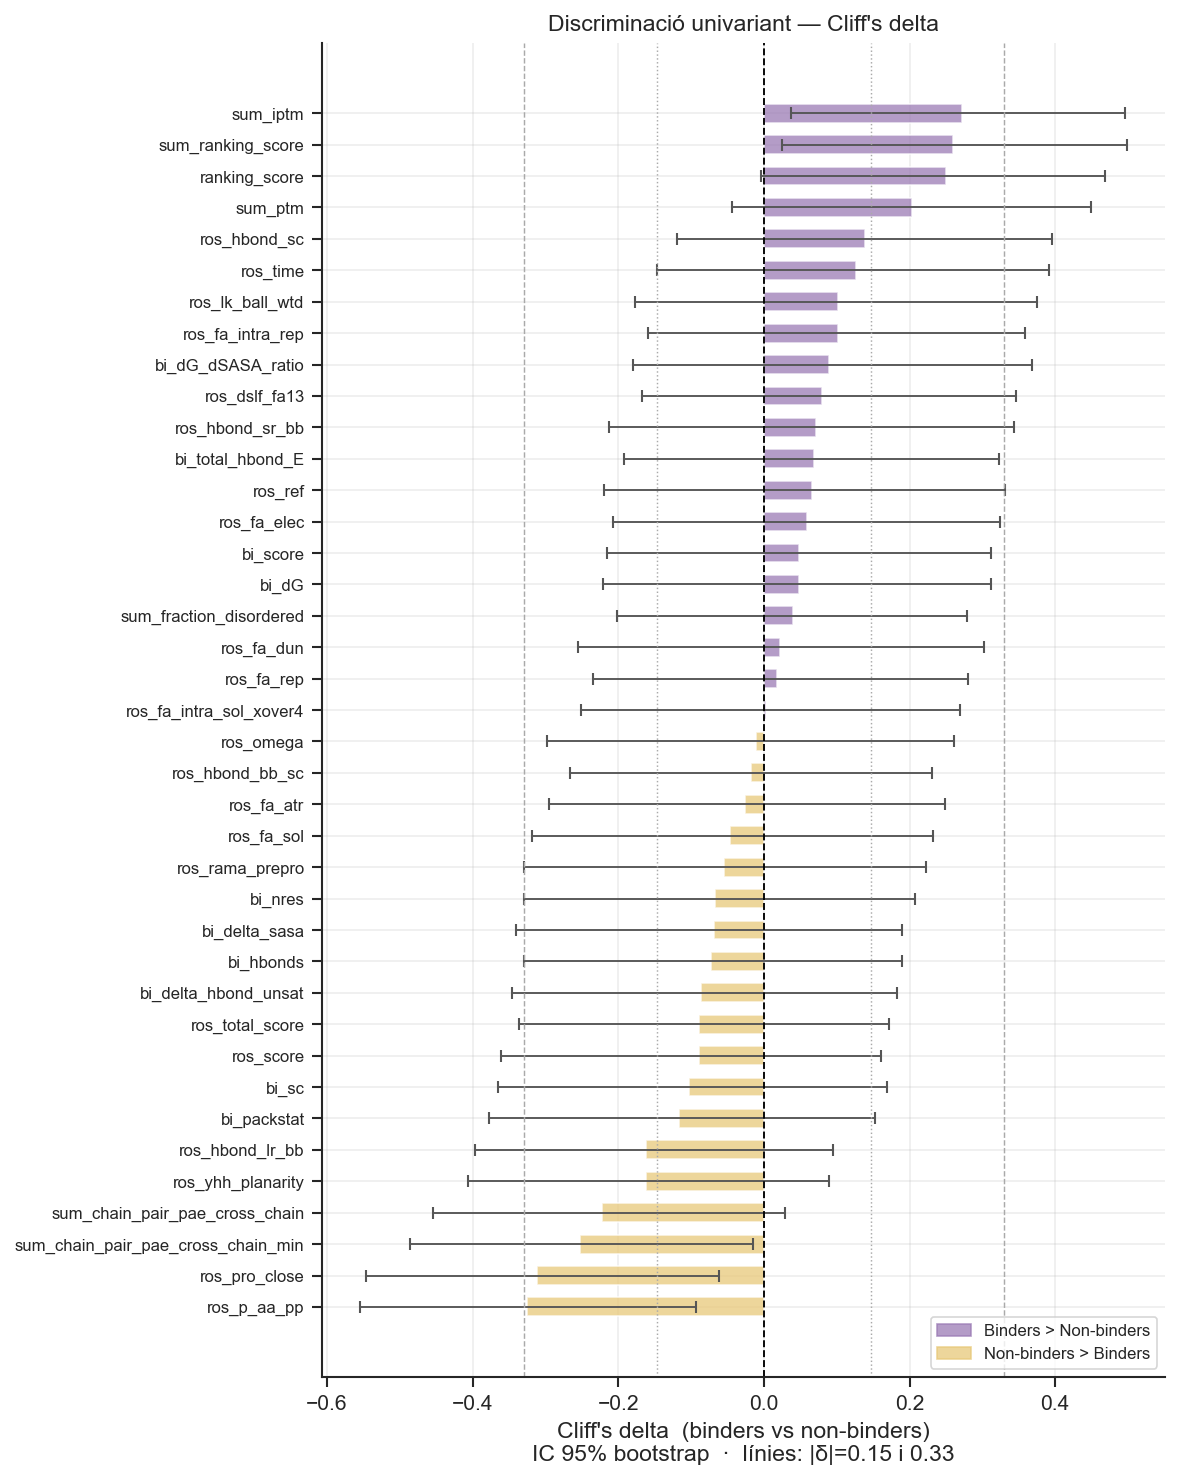

In [72]:
top6 = stats.head(6)['metric'].tolist()

fig, ax = plt.subplots(figsize=(8, 10))

df_plot = stats.sort_values('delta').reset_index(drop=True)
y = np.arange(len(df_plot))

colors = [col_binder if d > 0 else col_nonbinder for d in df_plot['delta']]
ax.barh(y, df_plot['delta'], xerr=[df_plot['delta'] - df_plot['ci_lo'],
                                    df_plot['ci_hi'] - df_plot['delta']],
        color=colors, alpha=0.75, height=0.6,
        error_kw=dict(elinewidth=0.9, capsize=3, ecolor='#555555'))
ax.axvline(0, color='black', lw=0.9, ls='--')

for x, ls in [(0.147, ':'), (0.33, '--')]:
    for s in [-1, 1]:
        ax.axvline(s*x, color='#aaaaaa', lw=0.7, ls=ls)

short = lambda m: m.replace('binding_interface_','bi_').replace('rosetta_','ros_')                   .replace('summary_','sum_').replace('_mean','').replace('_A_B','')
ax.set_yticks(y)
ax.set_yticklabels([short(m) for m in df_plot['metric']], fontsize=8)
ax.set_xlabel("Cliff's delta  (binders vs non-binders)\nIC 95% bootstrap  ·  línies: |δ|=0.15 i 0.33")
ax.set_title("Discriminació univariant — Cliff's delta")

binder_patch    = mpatches.Patch(color=col_binder,  alpha=0.75, label='Binders > Non-binders')
nonbinder_patch = mpatches.Patch(color=col_nonbinder, alpha=0.75, label='Non-binders > Binders')
ax.legend(handles=[binder_patch, nonbinder_patch], fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES / 'bloc1a_forest_plot.png')
plt.show()


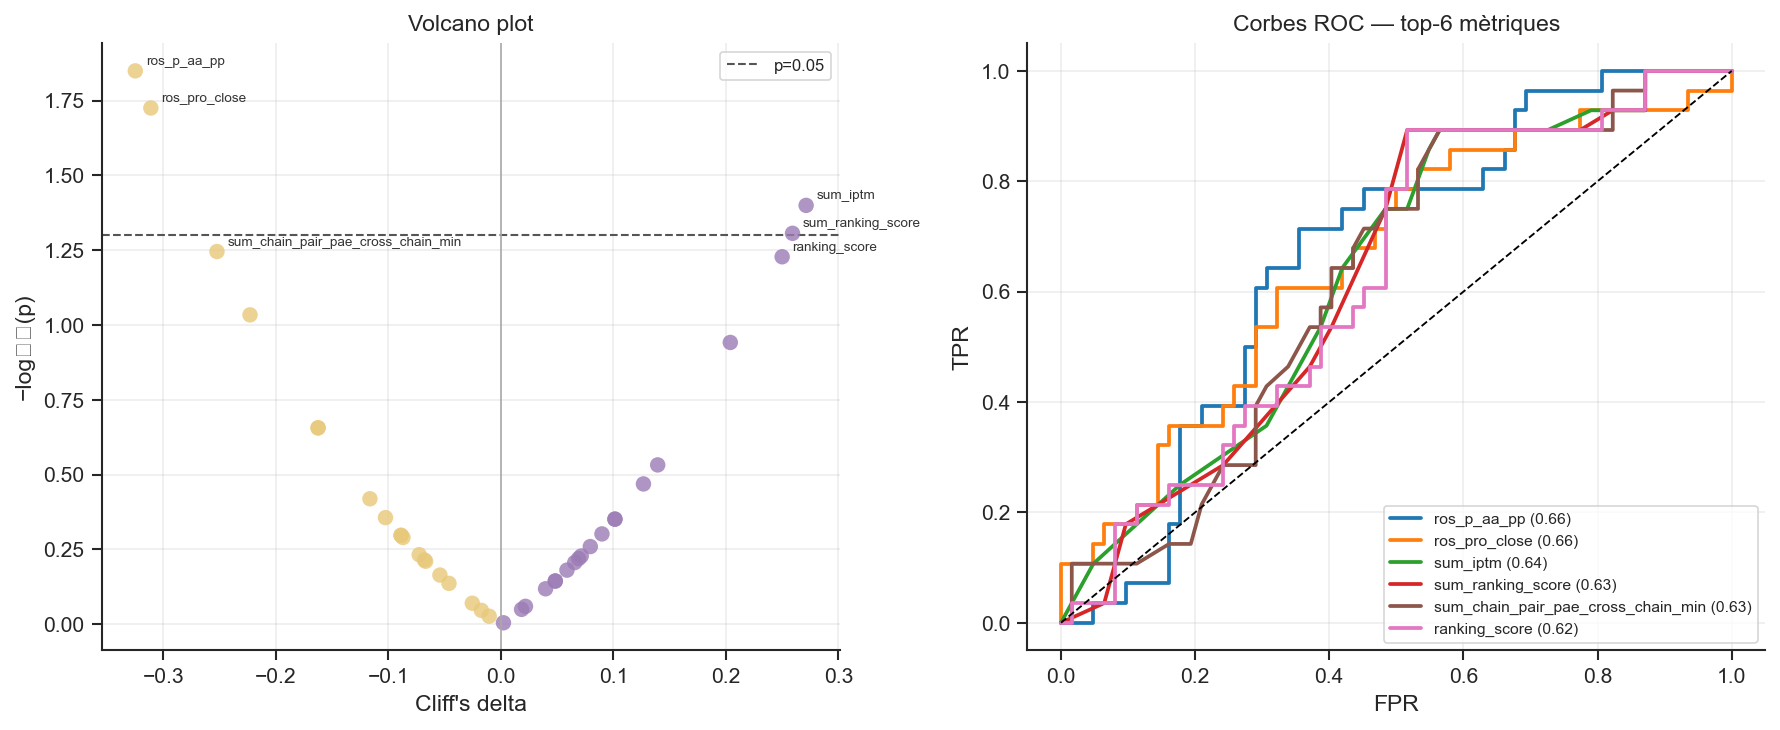

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Volcano plot 
ax = axes[0]
for _, row in stats.iterrows():
    y_val = -np.log10(row['p']) if row['p'] > 0 else 0
    sig   = row['p_fdr'] < 0.05
    ax.scatter(row['delta'], y_val,
               color=col_binder if row['delta'] > 0 else col_nonbinder,
               s=55, alpha=0.80, edgecolors='none',
               zorder=4 if abs(row['delta']) > 0.20 else 2)

for _, row in stats.head(6).iterrows():
    y_val = -np.log10(row['p'])
    lbl   = short(row['metric'])
    ax.annotate(lbl, (row['delta'], y_val), fontsize=6.5,
                xytext=(5, 3), textcoords='offset points', color='#333333')

ax.axhline(-np.log10(0.05), color='#555555', ls='--', lw=1, label='p=0.05')
ax.axvline(0, color='#aaaaaa', lw=0.8)
ax.set_xlabel("Cliff's delta")
ax.set_ylabel('−log₁₀(p)')
ax.set_title('Volcano plot')
ax.legend(fontsize=8)
sns.despine(ax=ax)

# Corbes ROC (top-6)
ax = axes[1]
colors_roc = plt.cm.tab10(np.linspace(0, 0.65, 6))
for i, feat in enumerate(top6):
    sub  = pd.DataFrame({'v': pd.to_numeric(df_labeled[feat], errors='coerce'),
                         'l': df_labeled['Binding']}).dropna()
    a    = roc_auc_score(sub['l'].astype(int), sub['v'])
    if a < 0.5:
        sub['v'], a = -sub['v'], 1 - a
    fpr, tpr, _ = roc_curve(sub['l'].astype(int), sub['v'])
    lbl = short(feat)
    ax.plot(fpr, tpr, color=colors_roc[i], lw=1.8, label=f'{lbl} ({a:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.9)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Corbes ROC — top-6 mètriques')
ax.legend(fontsize=7.5, loc='lower right')
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURES / 'bloc1b_volcano_roc.png')
plt.show()


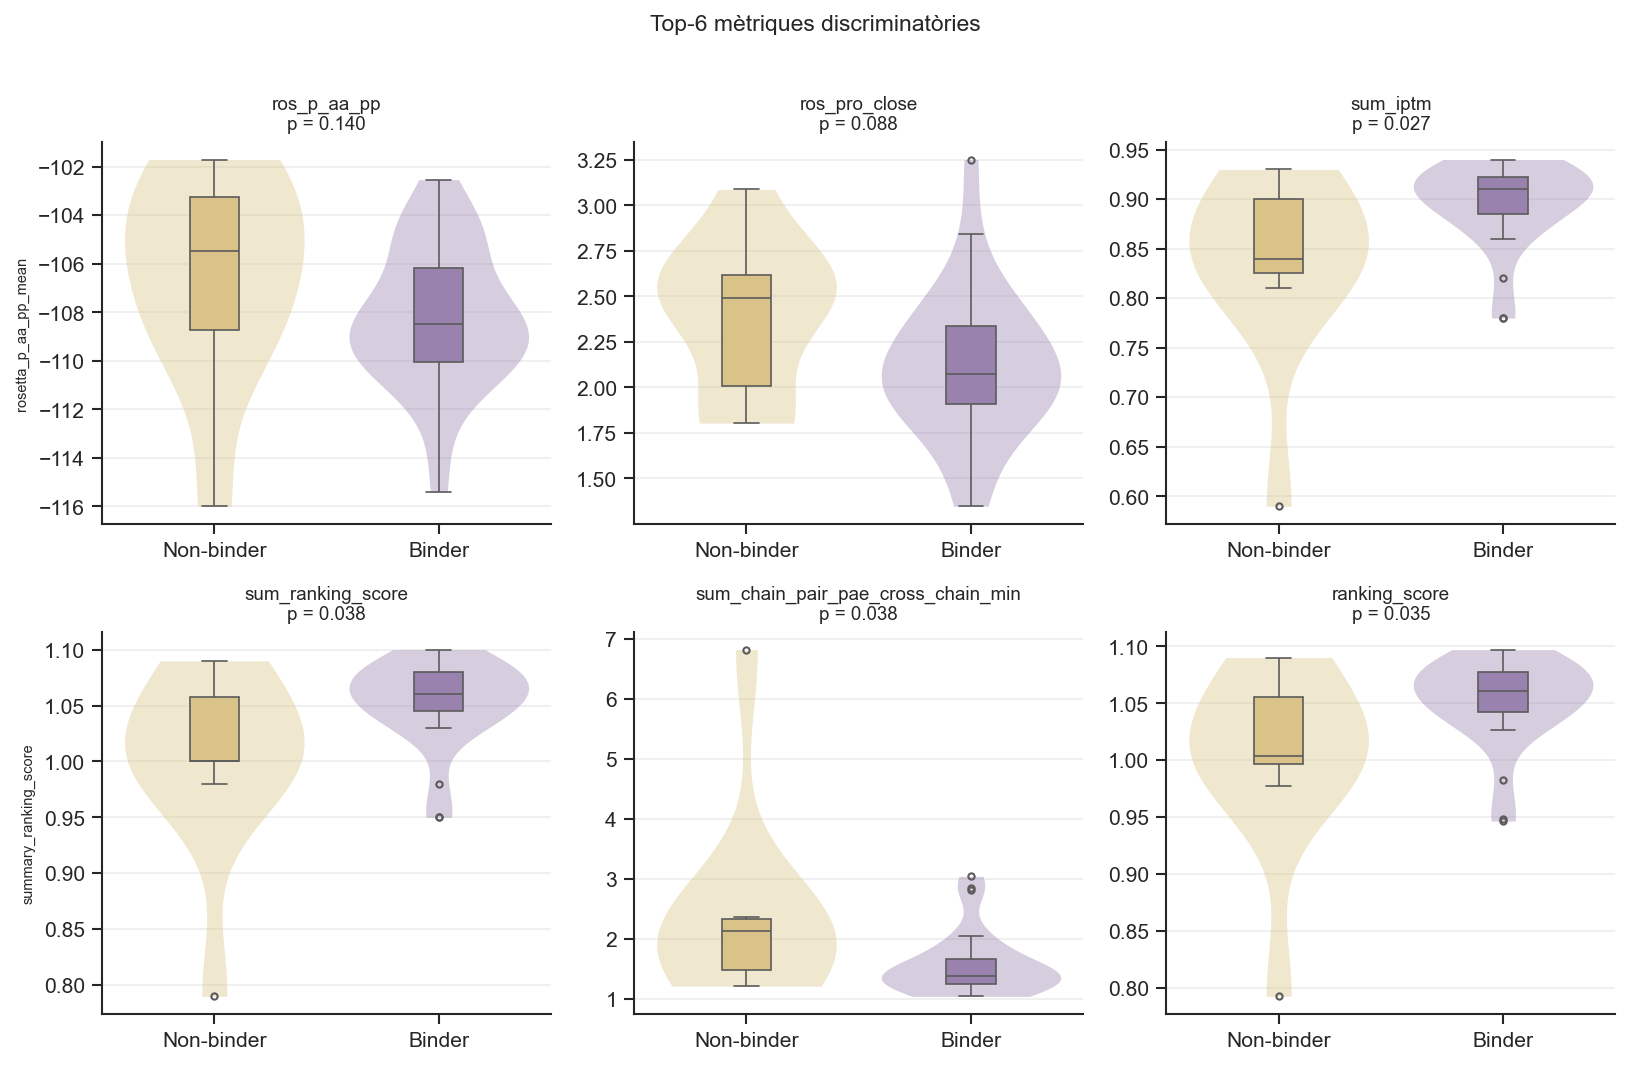

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes = axes.flatten()

for i, feat in enumerate(top6):
    ax  = axes[i]
    d   = df_labeled[['GroupLabel', feat, 'binding_strength']].copy()
    d[feat] = pd.to_numeric(d[feat], errors='coerce')
    d   = d.dropna()

    xb  = d.loc[d['GroupLabel']=='Binder',     feat].values
    xnb = d.loc[d['GroupLabel']=='Non-binder', feat].values
    _, p = mannwhitneyu(xnb, xb, alternative='two-sided')
    p_str = f'p = {p:.3f}' if p >= 0.001 else f'p = {p:.1e}'

    sns.violinplot(data=d, x='GroupLabel', y=feat,
                   order=['Non-binder', 'Binder'],
                   palette=class_colors, inner=None, cut=0,
                   linewidth=0, alpha=0.40, ax=ax)
    sns.boxplot(data=d, x='GroupLabel', y=feat,
                order=['Non-binder', 'Binder'],
                palette=class_colors, width=0.22, fliersize=3,
                linewidth=0.8, ax=ax)

    ax.set_title(f'{short(feat)}\n{p_str}', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel(feat if i % 3 == 0 else '', fontsize=7)
    sns.despine(ax=ax)

fig.suptitle('Top-6 mètriques discriminatòries', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'bloc1c_violin_top6.png')
plt.show()


---
## Bloc 2 — Redundància i col·linealitat

Amb 39 mètriques candidates cal comprovar si aporten informació independent abans d'usar-les en cap model. Quan dues mètriques estan molt correlacionades, un model multivariant no pot separar la seva contribució individual i els coeficients esdevenen inestables o arbitraris. 

Es calculen la matriu de correlació de Pearson, reordenada per clustering jeràrquic per fer visibles els blocs de mètriques redundants, i el factor d'inflació de la variança (VIF), que quantifica quant s'infla la incertesa del coeficient d'una mètrica a causa de la seva correlació amb la resta. Un VIF superior a 10 indica col·linealitat severa.

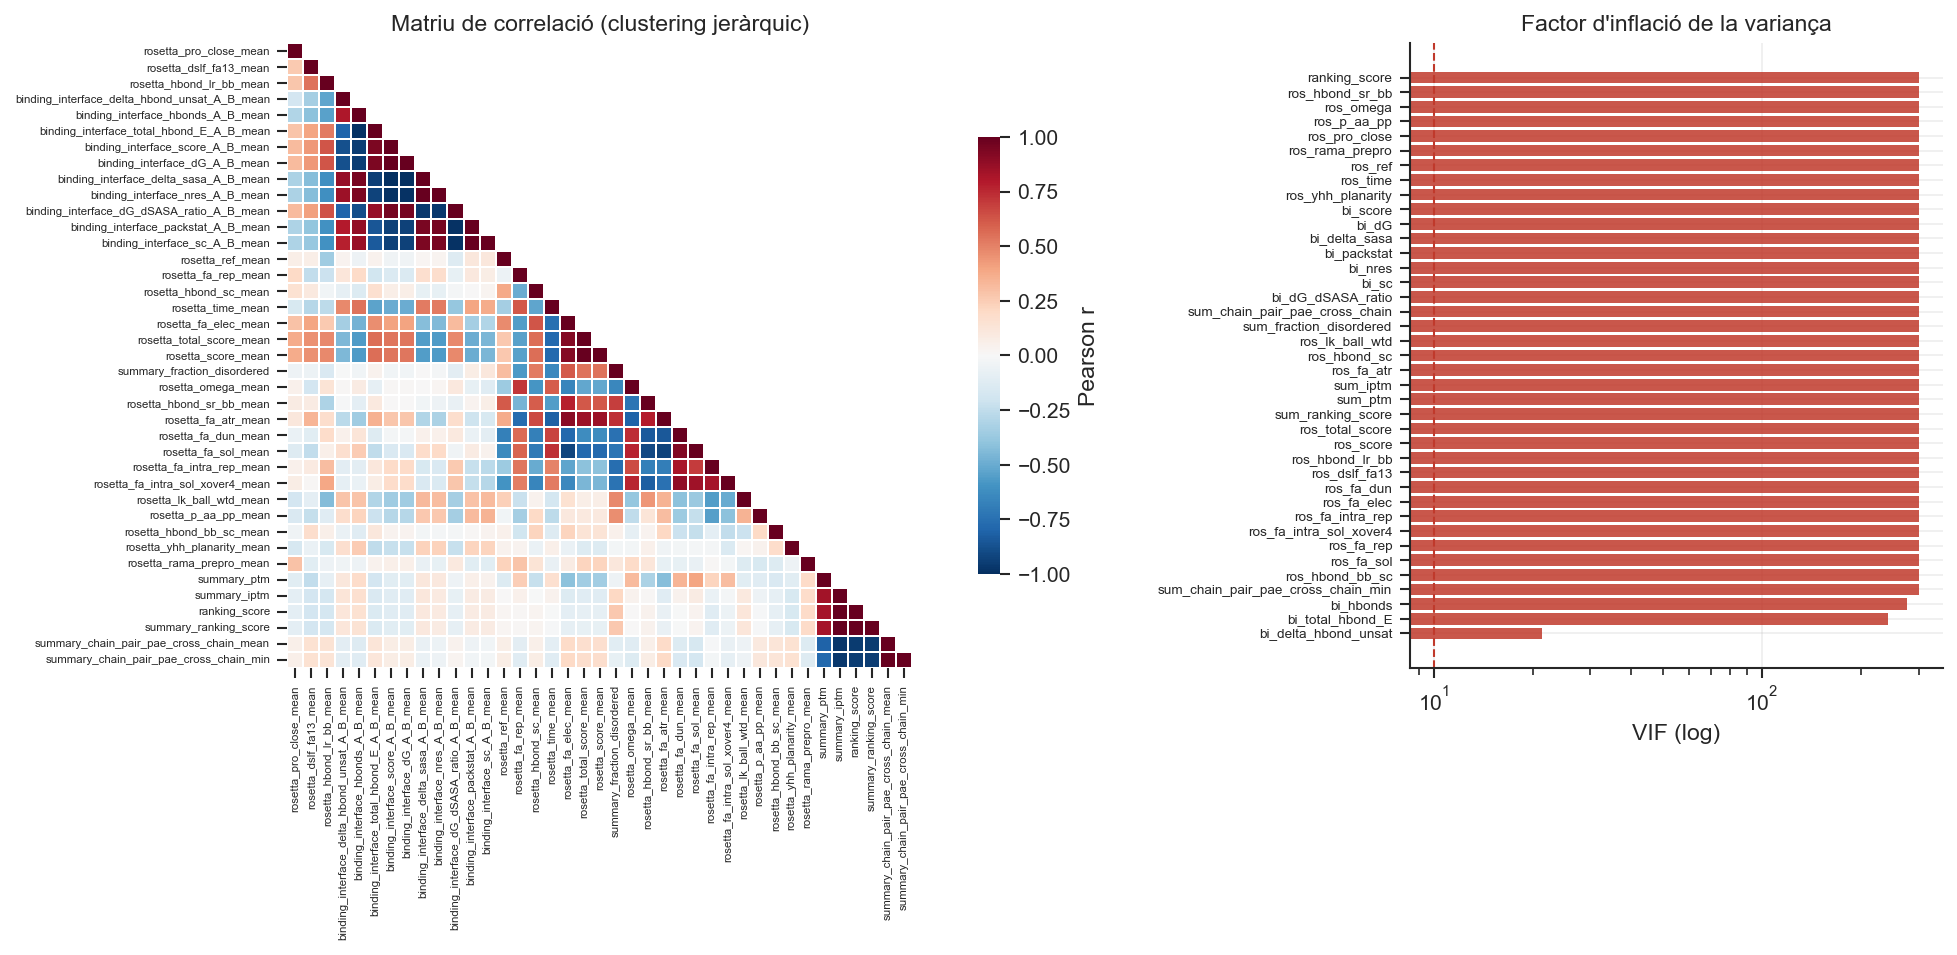

Parelles amb |r| > 0.85: 60
  ranking_score — sum_ranking_score: r=1.000
  ros_total_score — ros_score: r=1.000
  bi_score — bi_dG: r=1.000
  ranking_score — sum_iptm: r=0.997
  sum_iptm — sum_ranking_score: r=0.997
  sum_chain_pair_pae_cross_chain — sum_chain_pair_pae_cross_chain_min: r=0.997
  bi_delta_sasa — bi_nres: r=0.996
  bi_score — bi_delta_sasa: r=-0.994


In [75]:
X_num = df_labeled[metrics].apply(pd.to_numeric, errors='coerce')
corr  = X_num.corr()

# Clustering
dist = ((1 - corr.abs()) / 2).clip(lower=0)
np.fill_diagonal(dist.values, 0)
dist = (dist + dist.T) / 2
lnk  = linkage(squareform(dist.values, checks=False), method='average')
idx  = leaves_list(lnk)
corr_ord = corr.iloc[idx, idx]

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5),
                          gridspec_kw={'width_ratios': [2.5, 1]})

mask = np.triu(np.ones_like(corr_ord, dtype=bool), k=1)
sns.heatmap(corr_ord, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.1, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
            ax=axes[0], xticklabels=True, yticklabels=True)
axes[0].tick_params(axis='both', labelsize=5.5)
axes[0].set_title('Matriu de correlació (clustering jeràrquic)')

# VIF
vif_data = []
X_vif = X_num.dropna()
X_vif = X_vif[[c for c in X_vif.columns if X_vif[c].nunique() > 1]]
for i, col in enumerate(X_vif.columns):
    try:
        v = variance_inflation_factor(X_vif.values, i)
    except Exception:
        v = np.inf
    vif_data.append({'metric': col, 'vif': min(float(v), 300)})
vif_df = pd.DataFrame(vif_data).sort_values('vif', ascending=False)
vif_df.to_csv(FIGURES / 'bloc2_vif.csv', index=False)

colors_vif = ['#c0392b' if v >= 10 else '#f39c12' if v >= 5 else '#27ae60'
               for v in vif_df['vif']]
axes[1].barh(range(len(vif_df))[::-1], vif_df['vif'],
             color=colors_vif, alpha=0.85, edgecolor='none')
axes[1].axvline(10, color='#c0392b', ls='--', lw=1)
axes[1].set_xscale('log')
axes[1].set_yticks(range(len(vif_df))[::-1])
axes[1].set_yticklabels([short(m) for m in vif_df['metric']], fontsize=6.5)
axes[1].set_xlabel('VIF (log)')
axes[1].set_title('Factor d\'inflació de la variança')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIGURES / 'bloc2_correlation_vif.png')
plt.show()

high = [(corr.columns[i], corr.columns[j], round(corr.iloc[i,j], 3))
        for i in range(len(corr.columns))
        for j in range(i+1, len(corr.columns))
        if abs(corr.iloc[i,j]) > 0.85]
print(f'Parelles amb |r| > 0.85: {len(high)}')
for a, b, r in sorted(high, key=lambda x: -abs(x[2]))[:8]:
    print(f'  {short(a)} — {short(b)}: r={r:.3f}')


### Selecció del conjunt reduït de mètriques

L'anàlisi de correlació i VIF revela diversos blocs de mètriques pràcticament idèntiques: iPTM, ranking score i PAE cross-chain es mouen juntes (r > 0.97), igual que ΔG i ΔSASA (r = −0.99) o hbonds i total_hbond_E (r = −0.99). Usar totes elles simultàniament en un model introdueix multicolinealitat severa sense afegir informació nova.

Per resoldre-ho es selecciona un representant per cada bloc, prioritzant la mètrica amb major senyal univariant (menor p-valor o major AUC al Bloc 1) quan hi ha diverses candidates equivalents. El resultat és un conjunt de 14 mètriques que conserven la major part de la informació disponible sense redundància. Aquest és el conjunt que s'utilitza a la PCA i al model predictiu.

In [76]:
REDUCED = [
    'summary_iptm',                               # Representa el bloc iPTM/ranking/PAE (r > 0.97)
    'summary_ptm',
    'summary_fraction_disordered',
    'binding_interface_dG_A_B_mean',              # Representa el bloc dG/ΔSASA/score (r > 0.99)
    'binding_interface_packstat_A_B_mean',
    'binding_interface_hbonds_A_B_mean',          # Representa el bloc hbonds/total_hbond_E (r = −0.99)
    'binding_interface_sc_A_B_mean',
    'binding_interface_delta_hbond_unsat_A_B_mean',
    'rosetta_total_score_mean',                   # Representa el bloc total_score/score (r = 1.0)
    'rosetta_p_aa_pp_mean',                       # Millor p univariant
    'rosetta_pro_close_mean',                     # Segon millor p univariant
    'rosetta_hbond_lr_bb_mean',
    'rosetta_fa_elec_mean',
    'rosetta_fa_rep_mean',
]
REDUCED = [m for m in REDUCED if m in df_labeled.columns]

print(f'Mètriques reduïdes per al modelatge: {len(REDUCED)}')
for m in REDUCED:
    row = stats[stats['metric']==m]
    if not row.empty:
        r = row.iloc[0]
        print(f'  {short(m):<22}  p={r["p"]:.3f}  AUC={r["auc"]:.3f}  δ={r["delta"]:+.3f}')


Mètriques reduïdes per al modelatge: 14
  sum_iptm                p=0.040  AUC=0.636  δ=+0.271
  sum_ptm                 p=0.114  AUC=0.602  δ=+0.204
  sum_fraction_disordered  p=0.762  AUC=0.520  δ=+0.040
  bi_dG                   p=0.718  AUC=0.524  δ=+0.048
  bi_packstat             p=0.381  AUC=0.558  δ=-0.116
  bi_hbonds               p=0.586  AUC=0.536  δ=-0.073
  bi_sc                   p=0.441  AUC=0.551  δ=-0.103
  bi_delta_hbond_unsat    p=0.513  AUC=0.543  δ=-0.087
  ros_total_score         p=0.505  AUC=0.544  δ=-0.089
  ros_p_aa_pp             p=0.014  AUC=0.662  δ=-0.325
  ros_pro_close           p=0.019  AUC=0.656  δ=-0.311
  ros_hbond_lr_bb         p=0.221  AUC=0.581  δ=-0.162
  ros_fa_elec             p=0.660  AUC=0.529  δ=+0.059
  ros_fa_rep              p=0.893  AUC=0.509  δ=+0.018


---
## Bloc 3 — Reducció de dimensionalitat (PCA)

Es realitza una PCA sobre el conjunt reduït de mètriques estandarditzades per explorar si hi ha separació entre classes en l'espai de baixa dimensionalitat.

El biplot de càrregues permet identificar quines mètriques contribueixen més a cada component. Cal tenir en compte que amb n=90 i 28 positius la projecció als dos primers components pot no capturar tot el senyal discriminant.

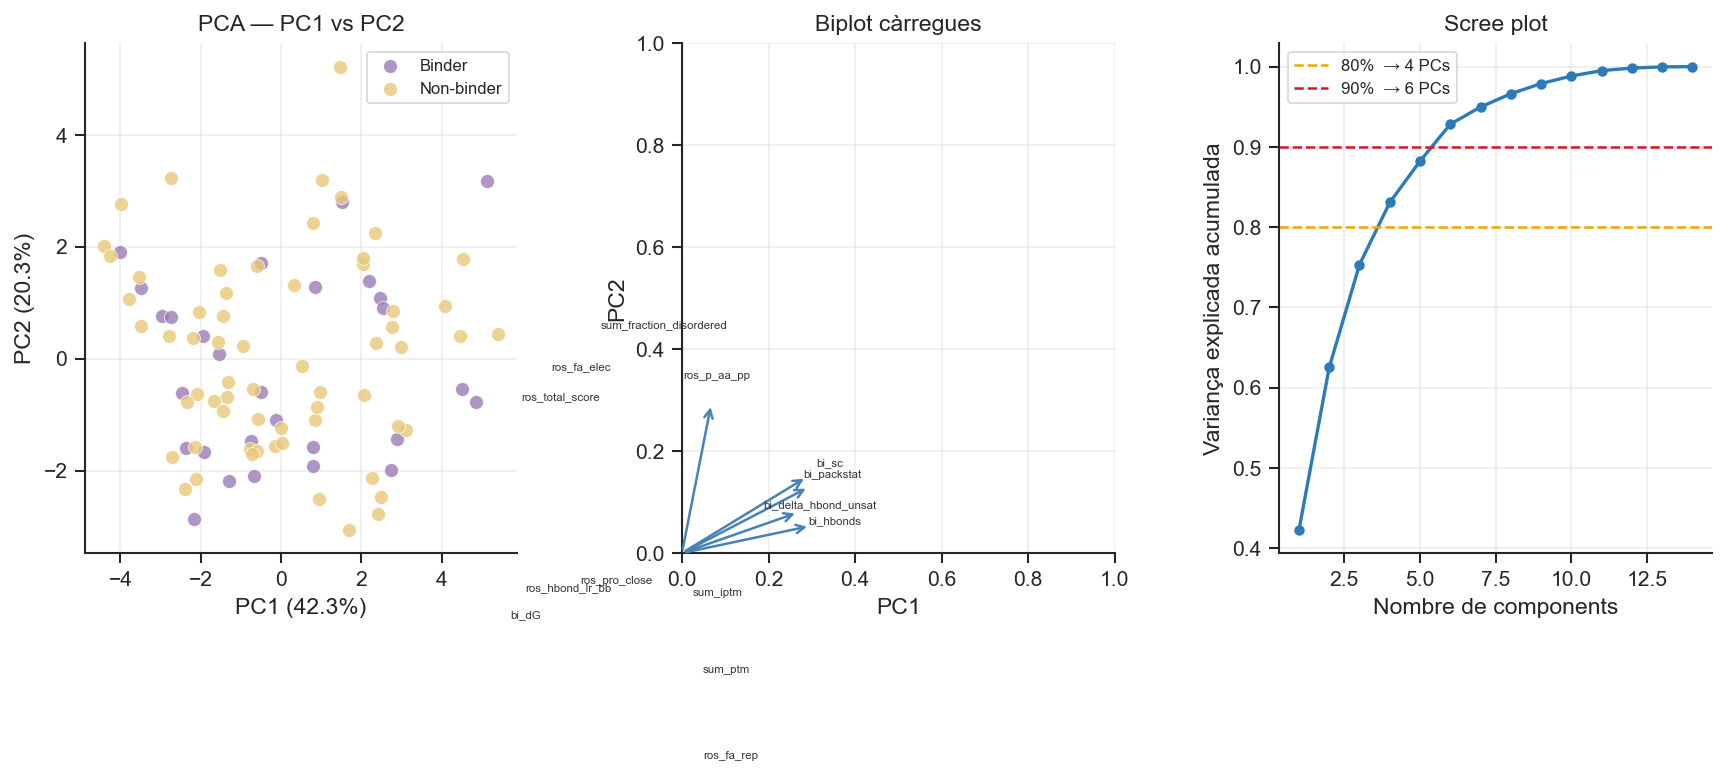

PC1+PC2: 62.5% de la variança total


In [77]:
X_r = df_labeled[REDUCED].apply(pd.to_numeric, errors='coerce')
y   = df_labeled['Binding'].astype(int).values
gl  = df_labeled['GroupLabel'].values

# L'escalat és necessari perquè les mètriques estan en escales molt diferents
pipe_pca = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('scl', StandardScaler()),
                     ('pca', PCA(random_state=42))])
Xp = pipe_pca.fit_transform(X_r)
pca = pipe_pca.named_steps['pca']
var = pca.explained_variance_ratio_

fig = plt.figure(figsize=(14, 4.5))
gs  = fig.add_gridspec(1, 3, wspace=0.38)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

for grp, col in class_colors.items():
    m = gl == grp
    ax1.scatter(Xp[m, 0], Xp[m, 1], c=col, s=45, alpha=0.80,
                edgecolors='white', lw=0.4, label=grp)
ax1.set_xlabel(f'PC1 ({var[0]:.1%})')
ax1.set_ylabel(f'PC2 ({var[1]:.1%})')
ax1.set_title('PCA — PC1 vs PC2')
ax1.legend(fontsize=8)
sns.despine(ax=ax1)

load = pca.components_[:2].T
scale = 0.38 / (np.abs(load).max() + 1e-9)
for j, feat in enumerate(REDUCED):
    ax2.annotate('', (load[j,0]*scale, load[j,1]*scale), (0, 0),
                 arrowprops=dict(arrowstyle='->', color='steelblue',
                                 lw=1.2, mutation_scale=10))
    ax2.text(load[j,0]*scale*1.18, load[j,1]*scale*1.18,
             short(feat), fontsize=5.5, ha='center', va='center', color='#333333')
ax2.axhline(0, color='#cccccc', lw=0.7)
ax2.axvline(0, color='#cccccc', lw=0.7)
ax2.set_title('Biplot càrregues')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
sns.despine(ax=ax2)

cum = np.cumsum(var)
ax3.plot(range(1, len(cum)+1), cum, 'o-', ms=4, lw=1.6, color='#2c7bb6')
ax3.axhline(0.80, color='#f0a500', ls='--', lw=1.2,
            label=f'80%  → {np.searchsorted(cum, 0.80)+1} PCs')
ax3.axhline(0.90, color='#d7191c', ls='--', lw=1.2,
            label=f'90%  → {np.searchsorted(cum, 0.90)+1} PCs')
ax3.set_xlabel('Nombre de components')
ax3.set_ylabel('Variança explicada acumulada')
ax3.set_title('Scree plot')
ax3.legend(fontsize=8)
sns.despine(ax=ax3)

plt.savefig(FIGURES / 'bloc3_pca.png')
plt.show()
print(f'PC1+PC2: {(var[0]+var[1]):.1%} de la variança total')


---
## Bloc 4 — Model predictiu

S'ajusta una regressió logística amb `class_weight='balanced'` (necessari pel desbalanç 28/62) sobre el conjunt reduït de mètriques estandarditzades. 

La selecció de la penalització (L1 o L2) i del paràmetre de regularització C es fa per cerca en graella interna (C ∈ [10⁻³, 10²]). La validació s'efectua amb k-fold estratificat repetit (5 folds × 10 repeticions) i es complementa amb un test de permutació (250 permutacions) per verificar que el senyal no és atribuïble a l'atzar. Com a comparació s'inclou un Random Forest poc profund (max_depth=3). Les mètriques d'avaluació principals són l'AUC, el F1 i la balanced accuracy; l'accuracy simple no s'utilitza per ser insensible al desbalanç de classes.

In [78]:
X_mod = df_labeled[REDUCED].apply(pd.to_numeric, errors='coerce')
y_mod = df_labeled['Binding'].astype(int).values

def build_pipeline(clf):
    return Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('scl', StandardScaler()), ('clf', clf)])

cv_in  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
C_VALS = np.logspace(-3, 2, 12)
grid_rows = []
for pen in ['l1', 'l2']:
    sol = 'liblinear' if pen == 'l1' else 'lbfgs'
    for C in C_VALS:
        lr   = LogisticRegression(penalty=pen, C=C, solver=sol,
                                   class_weight='balanced', max_iter=3000, random_state=42)     # class_weight='balanced' compensa el desbalanç 28/62: sense això el model tendeix a predir sempre Non-binder i obté accuracy = 68.9% sense aprendre res
        aucs = []                                                                               
        for tr, te in cv_in.split(X_mod, y_mod):
            build_pipeline(lr).fit(X_mod.iloc[tr], y_mod[tr])
            prob = build_pipeline(lr).fit(X_mod.iloc[tr], y_mod[tr]).predict_proba(X_mod.iloc[te])[:,1]
            if len(np.unique(y_mod[te])) == 2:
                aucs.append(roc_auc_score(y_mod[te], prob))
        grid_rows.append({'penalty': pen, 'C': C, 'auc': np.mean(aucs) if aucs else np.nan})

grid_df  = pd.DataFrame(grid_rows).sort_values('auc', ascending=False)
best     = grid_df.iloc[0]
BEST_PEN = best['penalty']
BEST_C   = best['C']
BEST_SOL = 'liblinear' if BEST_PEN == 'l1' else 'lbfgs'
print(f'Millor configuració: {BEST_PEN.upper()}, C={BEST_C:.4f}  (AUC intern={best["auc"]:.3f})')


Millor configuració: L1, C=0.1874  (AUC intern=0.672)


In [79]:
cv_out   = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
lr_best  = LogisticRegression(penalty=BEST_PEN, C=BEST_C, solver=BEST_SOL,
                               class_weight='balanced', max_iter=3000, random_state=42)
pipe_lr  = build_pipeline(lr_best)

mean_fpr = np.linspace(0, 1, 100)
tprs, aucs_cv, f1s, baccs, coefs = [], [], [], [], []

for tr, te in cv_out.split(X_mod, y_mod):
    pipe_lr.fit(X_mod.iloc[tr], y_mod[tr])
    prob = pipe_lr.predict_proba(X_mod.iloc[te])[:,1]
    pred = pipe_lr.predict(X_mod.iloc[te])
    yt   = y_mod[te]
    if len(np.unique(yt)) == 2:
        fpr_, tpr_, _ = roc_curve(yt, prob)
        tprs.append(np.interp(mean_fpr, fpr_, tpr_))
        aucs_cv.append(roc_auc_score(yt, prob))
    f1s.append(f1_score(yt, pred, zero_division=0))
    baccs.append(balanced_accuracy_score(yt, pred))
    coefs.append(pipe_lr.named_steps['clf'].coef_[0])

mean_tpr, std_tpr = np.mean(tprs, axis=0), np.std(tprs, axis=0)
coef_df = pd.DataFrame({'feature': REDUCED,
                         'mean': np.mean(coefs, axis=0),
                         'std' : np.std(coefs, axis=0)}).sort_values('mean')

print(f'Regressió logística ({BEST_PEN.upper()}, C={BEST_C:.3f}):')
print(f'  AUC          : {np.mean(aucs_cv):.3f} ± {np.std(aucs_cv):.3f}')   # Mitjana i dispersió entre folds
print(f'  F1            : {np.mean(f1s):.3f}')                              # Harmònica precisió-recall
print(f'  Balanced acc  : {np.mean(baccs):.3f}')                            # Accuracy corregida pel desbalanç
print(f'  Baseline acc  : {baseline:.3f}')                                  # Referència: model trivial

# Permutation test (per tal de verificar que el senyal no és atribuïble a l'atzar)
print('\nTest de permutació')
cv_perm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
obs_auc, perm_aucs, perm_p = permutation_test_score(
    build_pipeline(LogisticRegression(penalty=BEST_PEN, C=BEST_C, solver=BEST_SOL,
                                  class_weight='balanced', max_iter=3000, random_state=42)),
    X_mod, y_mod, scoring='roc_auc', cv=cv_perm,
    n_permutations=250, random_state=42, n_jobs=-1)
print(f'  AUC observat: {obs_auc:.3f}  |  p permutació: {perm_p:.3f}')


Regressió logística (L1, C=0.187):
  AUC          : 0.685 ± 0.124
  F1            : 0.543
  Balanced acc  : 0.646
  Baseline acc  : 0.689

Test de permutació
  AUC observat: 0.672  |  p permutació: 0.032


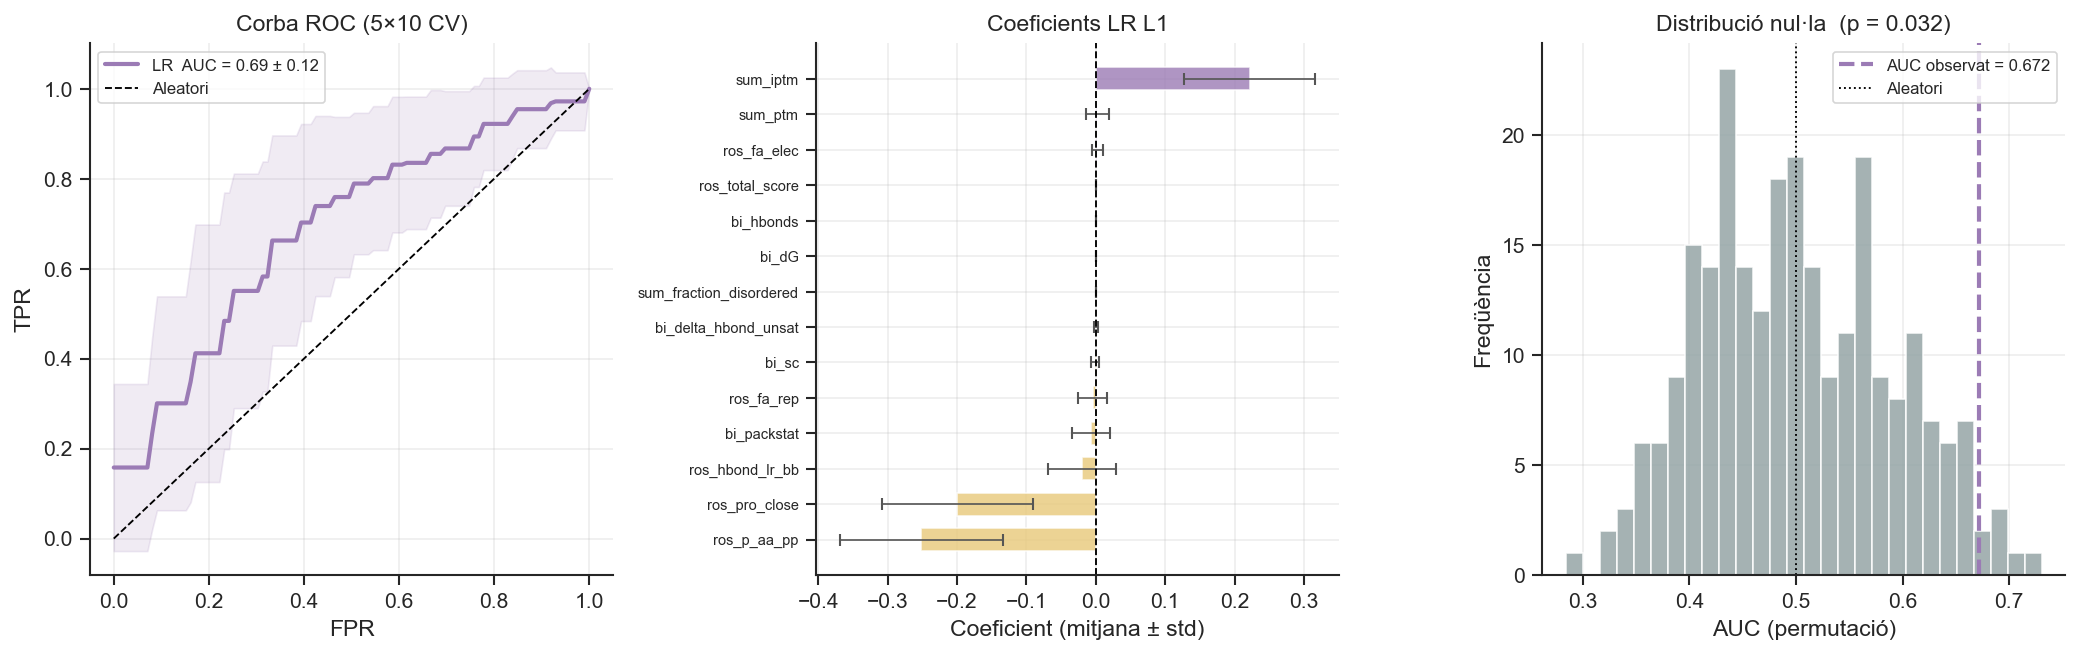

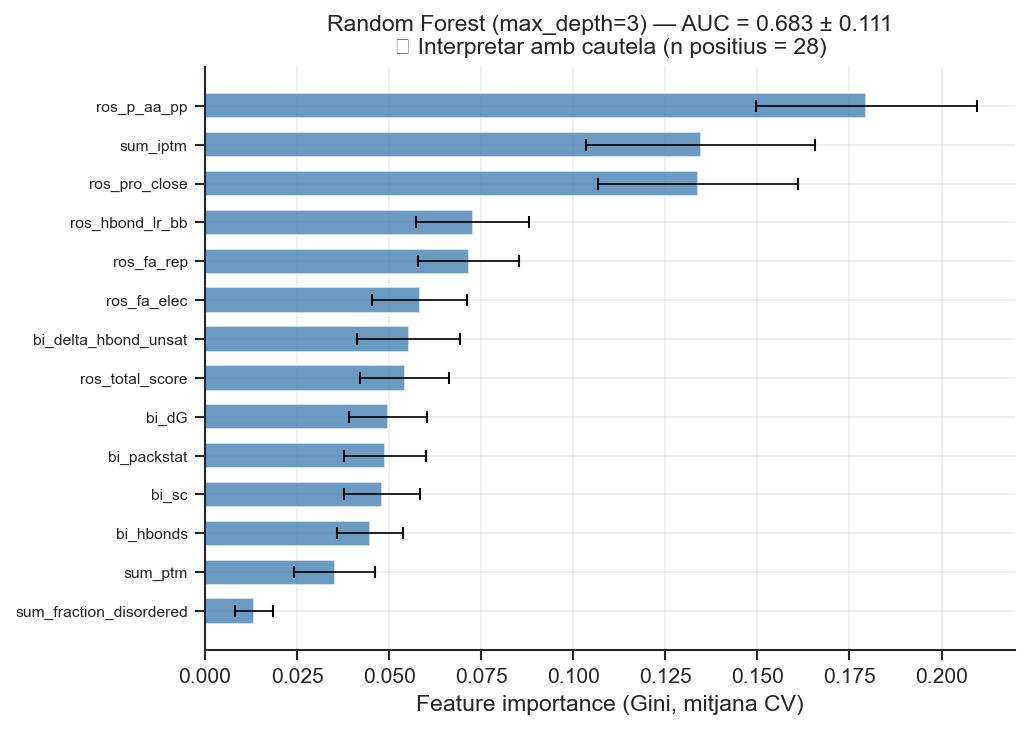

Random Forest:  AUC = 0.683 ± 0.111


,model,auc,f1,balanced_acc,perm_p
0,Baseline (majoria),0.500,0.000,0.500,NaN
1,LR L1 C=0.187,0.685,0.543,0.646,0.032
2,RF max_depth=3,0.683,NaN,NaN,NaN


In [80]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ROC CV
ax = axes[0]
ax.plot(mean_fpr, mean_tpr, color=col_binder, lw=2,
        label=f'LR  AUC = {np.mean(aucs_cv):.2f} ± {np.std(aucs_cv):.2f}')
ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                alpha=0.15, color=col_binder)
ax.plot([0, 1], [0, 1], 'k--', lw=0.9, label='Aleatori')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Corba ROC (5×10 CV)')
ax.legend(fontsize=8)
sns.despine(ax=ax)

# Coeficients
ax = axes[1]
colors_c = [col_binder if v >= 0 else col_nonbinder for v in coef_df['mean']]
ax.barh([short(f) for f in coef_df['feature']], coef_df['mean'],
        xerr=coef_df['std'], color=colors_c, alpha=0.80, height=0.65,
        error_kw=dict(elinewidth=0.8, capsize=3, ecolor='#555555'))
ax.axvline(0, color='black', lw=0.9, ls='--')
ax.set_xlabel('Coeficient (mitjana ± std)')
ax.set_title(f'Coeficients LR {BEST_PEN.upper()}')
ax.tick_params(axis='y', labelsize=7)
sns.despine(ax=ax)

# Distribució nul·la
ax = axes[2]
ax.hist(perm_aucs, bins=28, color='#95a5a6', alpha=0.85, edgecolor='white')
ax.axvline(obs_auc, color=col_binder, lw=2, ls='--',
           label=f'AUC observat = {obs_auc:.3f}')
ax.axvline(0.5, color='black', lw=0.9, ls=':', label='Aleatori')
ax.set_xlabel('AUC (permutació)')
ax.set_ylabel('Freqüència')
ax.set_title(f'Distribució nul·la  (p = {perm_p:.3f})')
ax.legend(fontsize=8)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURES / 'bloc4_model.png')
plt.show()

# Random Forest 
rf = RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=5,
                              class_weight='balanced', random_state=42, n_jobs=-1)
aucs_rf, imps = [], []
for tr, te in cv_out.split(X_mod, y_mod):
    build_pipeline(rf).fit(X_mod.iloc[tr], y_mod[tr])
    prob = build_pipeline(rf).fit(X_mod.iloc[tr], y_mod[tr]).predict_proba(X_mod.iloc[te])[:,1]
    if len(np.unique(y_mod[te])) == 2:
        aucs_rf.append(roc_auc_score(y_mod[te], prob))
    imps.append(build_pipeline(rf).fit(X_mod.iloc[tr], y_mod[tr]).named_steps['clf'].feature_importances_)

imp_df = pd.DataFrame({'feature': REDUCED,
                        'imp': np.mean(imps, axis=0),
                        'std': np.std(imps, axis=0)}).sort_values('imp')

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh([short(f) for f in imp_df['feature']], imp_df['imp'],
        xerr=imp_df['std'], color='steelblue', alpha=0.80, height=0.65,
        error_kw=dict(elinewidth=0.8, capsize=3))
ax.set_xlabel('Feature importance (Gini, mitjana CV)')
ax.set_title(f'Random Forest (max_depth=3) — AUC = {np.mean(aucs_rf):.3f} ± {np.std(aucs_rf):.3f}\n'
             f'⚠ Interpretar amb cautela (n positius = {int(y_mod.sum())})')
ax.tick_params(axis='y', labelsize=7.5)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / 'bloc4_rf_importances.png')
plt.show()

print(f'Random Forest:  AUC = {np.mean(aucs_rf):.3f} ± {np.std(aucs_rf):.3f}')

summary = pd.DataFrame([
    {'model': 'Baseline (majoria)', 'auc': 0.5, 'f1': 0.0, 'balanced_acc': 0.5},
    {'model': f'LR {BEST_PEN.upper()} C={BEST_C:.3f}',
     'auc': np.mean(aucs_cv), 'f1': np.mean(f1s), 'balanced_acc': np.mean(baccs),
     'perm_p': perm_p},
    {'model': 'RF max_depth=3',
     'auc': np.mean(aucs_rf)},
])
summary.to_csv(FIGURES / 'bloc4_model_summary.csv', index=False)
display(summary.round(3))


---
## Bloc 5 — Robustesa

Es comprova la sensibilitat dels resultats a dos factors: la presència de valors extrems i la incertesa en l'AUC. Per detectar outliers es combina el criteri IQR (1.5× per mètrica) amb el z-score robust (llindar 3.5). Es recalcula el Cliff's delta de les sis millors mètriques amb i sense els dissenys detectats com a extrems.

L'AUC de les sis millors mètriques s'estima amb intervals de confiança del 95% per bootstrap (2000 resamples) per visualitzar la incertesa associada a la mida de la mostra.

Outliers detectats (24): ['Complex2', 'Complex12', 'Complex13', 'Complex16', 'Complex18', 'Complex19', 'Complex21', 'Complex24', 'Complex36', 'Complex40', 'Complex46', 'Complex48', 'Complex49', 'Complex51', 'Complex53', 'Complex67', 'Complex68', 'Complex74', 'Complex75', 'Complex76', 'Complex78', 'Complex80', 'Complex89', 'Complex94']


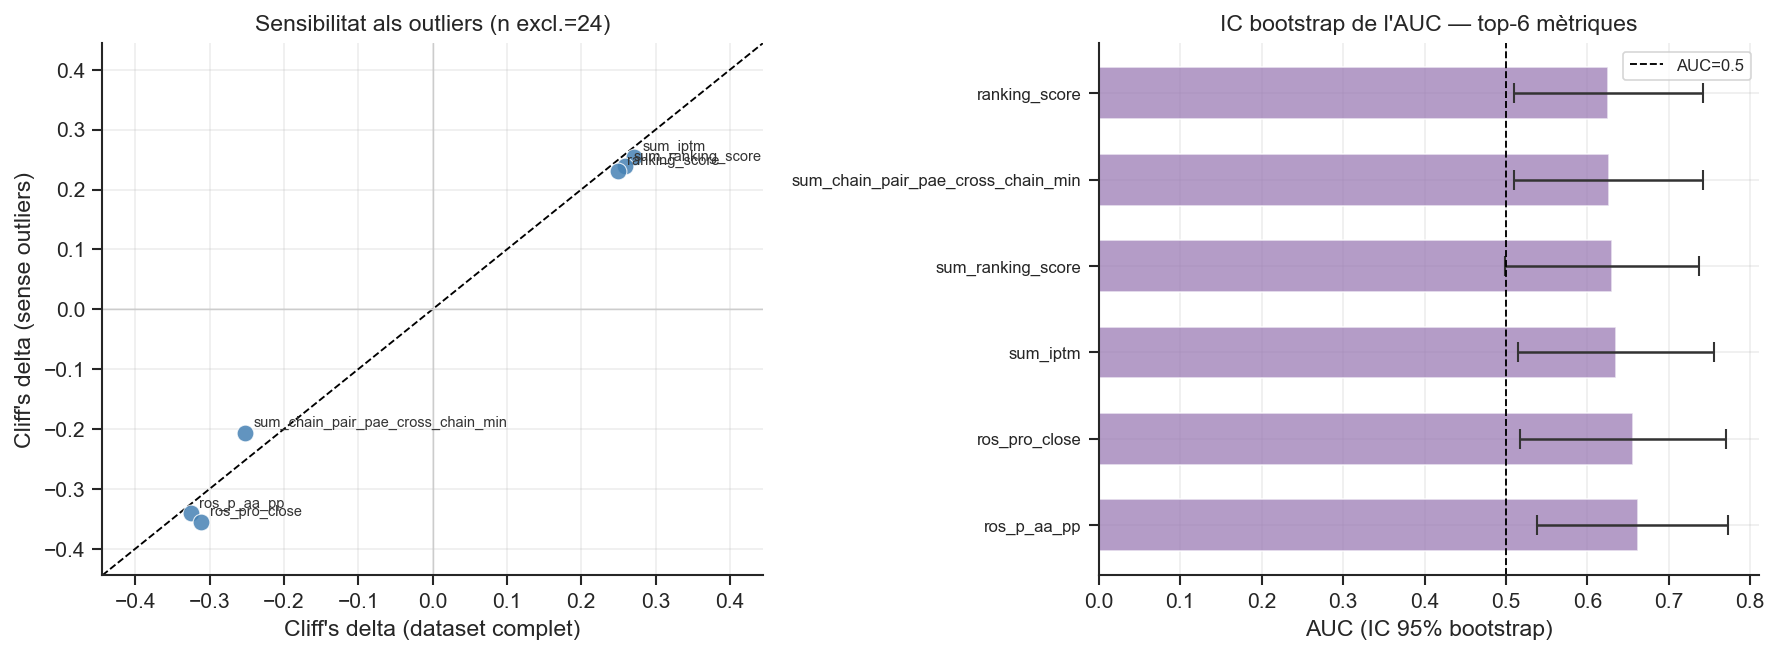

In [81]:
# Detecció d'outliers (IQR + z-score)
X_all  = df_labeled[metrics].apply(pd.to_numeric, errors='coerce')
iqr_cnt = np.zeros(len(df_labeled), int)
rz_max  = np.zeros(len(df_labeled))
for col in metrics:
    s = X_all[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr > 0:
        iqr_cnt += ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).fillna(False).astype(int).values
    med = np.nanmedian(s); mad = np.nanmedian(np.abs(s - med))
    if mad > 0:
        rz_max = np.maximum(rz_max, np.nan_to_num(0.6745*np.abs(s-med)/mad))

outlier_mask = (iqr_cnt >= 2) | (rz_max >= 3.5)
outlier_names = df_labeled.loc[outlier_mask, 'DesignName'].tolist()
print(f'Outliers detectats ({len(outlier_names)}): {outlier_names}')

df_no_out = df_labeled[~outlier_mask].copy()
stats_no_out = univariate_stats(df_no_out, top6)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
cd_full   = [stats.loc[stats['metric']==f, 'delta'].values[0] for f in top6]
cd_no_out = [stats_no_out.loc[stats_no_out['metric']==f, 'delta'].values[0]
             if f in stats_no_out['metric'].values else np.nan for f in top6]

lim = max(abs(min(cd_full+cd_no_out)), abs(max(cd_full+cd_no_out))) * 1.25
ax.scatter(cd_full, cd_no_out, s=65, color='steelblue', alpha=0.85,
           edgecolors='white', lw=0.5, zorder=3)
for cf, cn, f in zip(cd_full, cd_no_out, top6):
    if pd.notna(cn):
        ax.annotate(short(f), (cf, cn), fontsize=7,
                    xytext=(4, 3), textcoords='offset points', color='#333333')
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.9)
ax.axhline(0, color='#cccccc', lw=0.7); ax.axvline(0, color='#cccccc', lw=0.7)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Cliff's delta (dataset complet)")
ax.set_ylabel("Cliff's delta (sense outliers)")
ax.set_title(f"Sensibilitat als outliers (n excl.={len(outlier_names)})")
sns.despine(ax=ax)

# Bootstrap CI de l'AUC per a top-6
ax = axes[1]
rng   = np.random.default_rng(42)
auc_ci = []
for feat in top6:
    sub  = pd.DataFrame({'v': pd.to_numeric(df_labeled[feat], errors='coerce'),
                         'l': df_labeled['Binding']}).dropna()
    a    = roc_auc_score(sub['l'].astype(int), sub['v'])
    if a < 0.5:
        sub['v'], a = -sub['v'], 1-a
    bs   = []
    for _ in range(2000):
        idx  = rng.choice(len(sub), len(sub), replace=True)
        sl   = sub.iloc[idx]
        if sl['l'].nunique() == 2:
            bs.append(roc_auc_score(sl['l'].astype(int), sl['v']))
    auc_ci.append({'feat': feat, 'auc': a,
                      'lo': np.percentile(bs, 2.5), 'hi': np.percentile(bs, 97.5)})

ab = pd.DataFrame(auc_ci).sort_values('auc', ascending=False)
y  = range(len(ab))
ax.barh(list(y), ab['auc'], xerr=[ab['auc']-ab['lo'], ab['hi']-ab['auc']],
        color=col_binder, alpha=0.75, height=0.6,
        error_kw=dict(elinewidth=1.2, capsize=5, ecolor='#333333'))
ax.axvline(0.5, color='black', lw=0.9, ls='--', label='AUC=0.5')
ax.set_yticks(list(y))
ax.set_yticklabels([short(f) for f in ab['feat']], fontsize=8)
ax.set_xlabel('AUC (IC 95% bootstrap)')
ax.set_title('IC bootstrap de l\'AUC — top-6 mètriques')
ax.legend(fontsize=8)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURES / 'bloc5_robustesa.png')
plt.show()


In [82]:
# Guardar llista de figures
print('\nFigures desades a:', FIGURES)
for f in sorted(FIGURES.iterdir()):
    print(f'  {f.name}')



Figures desades a: /Users/bertaguiu/projects/Scripts/il7ra/figures
  bloc0_overview.png
  bloc0a_class_balance.png
  bloc0b_zscore_violin_swarm_panel.png
  bloc1_univariate_stats.csv
  bloc1a_forest_plot.png
  bloc1a_forest_plot_cliffs_delta.png
  bloc1b_volcano_plot.png
  bloc1b_volcano_roc.png
  bloc1c_roc_curves_top6.png
  bloc1c_violin_top6.png
  bloc1d_violin_box_top6.png
  bloc2_correlation_vif.png
  bloc2_high_corr_pairs.csv
  bloc2_reduced_metrics_list.csv
  bloc2_vif.csv
  bloc2a_correlation_heatmap_clustered.png
  bloc2b_vif_barchart.png
  bloc3_pca.png
  bloc3_pca_biplot_variance.png
  bloc4_lr_coefficients.csv
  bloc4_lr_grid_search.csv
  bloc4_model.png
  bloc4_model_comparison.csv
  bloc4_model_results.png
  bloc4_model_summary.csv
  bloc4_permutation_scores.csv
  bloc4_rf_importances.csv
  bloc4_rf_importances.png
  bloc5_outliers.csv
  bloc5_robustesa.png
  bloc5a_outlier_sensitivity_scatter.png
  bloc5b_auc_bootstrap_ci.csv
  bloc5b_auc_bootstrap_ci.png
  bloc5c_kd_se